# Heart Disease Risk Classification - CRISP-DM Framework

Nama : M. Rajab Fadhly Hartawibawa \
NIM : 09021282328046 \
TI REG A 23

Notebook Ini digunakan untuk simulasi pipeline model Logistic Regression & Random Forest Classifier untuk klasifikasi risiko penyakit jantung berdasar profil pasien (pada dataset)

## 1. Business & Data Understanding
Load Library yang digunakan dan environtment pendukung.

In [111]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Set plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

In [112]:
from google.colab import files
import io
import os

# Create models directory in local Colab environment
os.makedirs('models', exist_ok=True)

# Load Dataset via Upload Button
print("Silakan upload file 'heart_disease_dataset_augmented.csv':")
uploaded = files.upload()

# Find the uploaded file name
target_file = None
for name in uploaded.keys():
    if 'heart_disease' in name.lower() and name.endswith('.csv'):
        target_file = name
        break

if target_file:
    df = pd.read_csv(io.BytesIO(uploaded[target_file]))
    # Clean column names (strip leading/trailing spaces)
    df.columns = df.columns.str.strip()
    print(f"Dataset '{target_file}' loaded successfully with shape: {df.shape}")
    display(df.head())
else:
    print("Error: File CSV tidak ditemukan dalam file yang diunggah.")
    # Creating a dummy placeholder to prevent syntax errors below if cell is run blindly
    df = pd.DataFrame(columns=['Patient_ID', 'Age', 'Gender', 'ChestPain', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Smoking', 'BMI', 'FamilyHistory', 'StressLevel', 'PhysicalActivity', 'HeartDisease'])
    df.columns = df.columns.str.strip()

Silakan upload file 'heart_disease_dataset_augmented.csv':


Saving heart_disease_final_250.csv to heart_disease_final_250 (2).csv
Dataset 'heart_disease_final_250 (2).csv' loaded successfully with shape: (250, 15)


,Patient_ID,Age,Gender,ChestPain,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Smoking,BMI,FamilyHistory,StressLevel,PhysicalActivity,HeartDisease
0,P001,63,Male,Asymptomatic,145,233,1,150,Yes,Yes,30.1,Yes,9,Rendah,1
1,P002,37,Male,Non-anginal,130,250,0,187,No,No,24.2,No,3,Tinggi,0
2,P003,41,Female,Atypical,130,204,0,172,No,No,22.8,No,4,Sedang,0
3,P004,56,Male,Typical,120,236,0,178,No,Yes,28.5,Yes,6,Sedang,1
4,P005,57,Female,Asymptomatic,140,354,0,163,Yes,No,31.2,Yes,8,Rendah,1


## 2. Exploratory Data Analysis (EDA)

Visualisasi Data Pasien untuk korelasi fitur, distribusi data dan Boxplot untuk melihat outlier dan perbandingan antar fitur dengan profil risiko

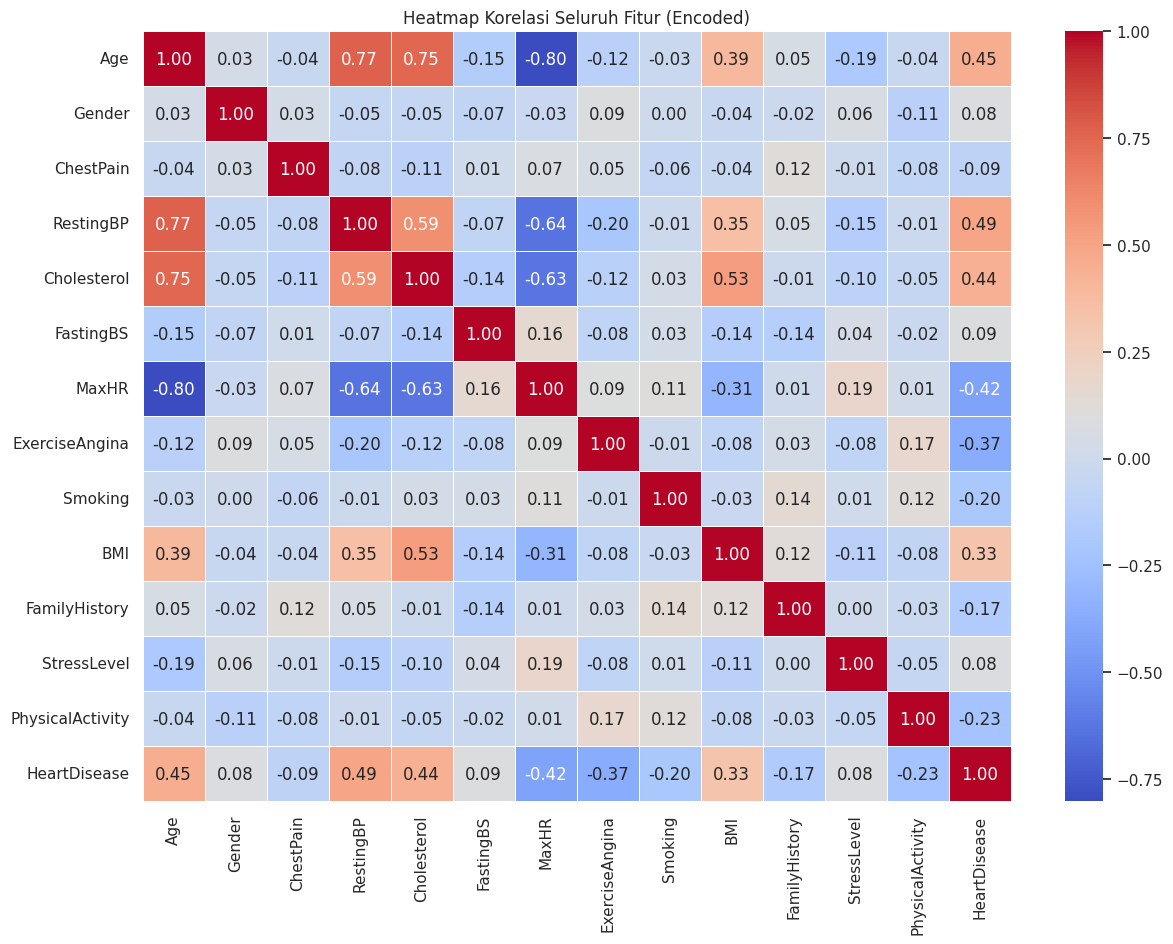

Insight: Heatmap ini menunjukkan hubungan linear antar fitur. Perhatikan korelasi positif/negatif yang kuat terhadap HeartDisease.


In [113]:
# 2.1 Correlation Heatmap (Including Categorical)
if not df.empty:
    plt.figure(figsize=(14, 10))
    # Create a copy for correlation analysis
    corr_df = df.copy()
    if 'Patient_ID' in corr_df.columns:
        corr_df = corr_df.drop('Patient_ID', axis=1)

    # Factorize categorical columns to include them in correlation
    for col in corr_df.select_dtypes(include=['object']).columns:
        corr_df[col] = pd.factorize(corr_df[col])[0]

    sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Heatmap Korelasi Seluruh Fitur (Encoded)')
    plt.show()
    print("Insight: Heatmap ini menunjukkan hubungan linear antar fitur. Perhatikan korelasi positif/negatif yang kuat terhadap HeartDisease.")

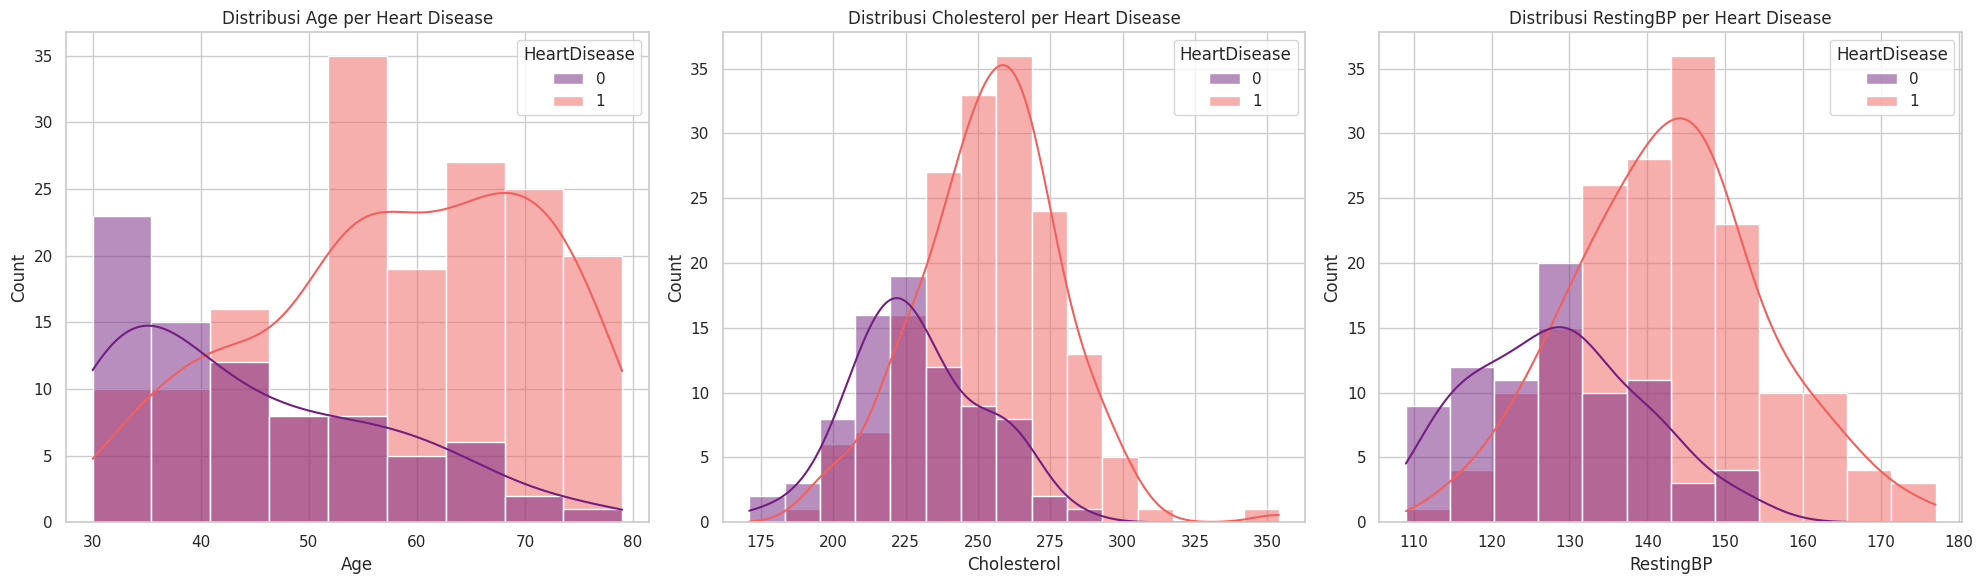

Insight: Pergeseran kurva ke arah kanan pada pasien Heart Disease menunjukkan nilai rata-rata yang lebih tinggi pada fitur tersebut.


In [114]:
# 2.2 Numerical Distribution (Age, Cholesterol, RestingBP)
if not df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    features = ['Age', 'Cholesterol', 'RestingBP']

    for i, col in enumerate(features):
        sns.histplot(data=df, x=col, hue='HeartDisease', kde=True, ax=axes[i], palette='magma')
        axes[i].set_title(f'Distribusi {col} per Heart Disease')

    plt.tight_layout()
    plt.show()
    print("Insight: Pergeseran kurva ke arah kanan pada pasien Heart Disease menunjukkan nilai rata-rata yang lebih tinggi pada fitur tersebut.")

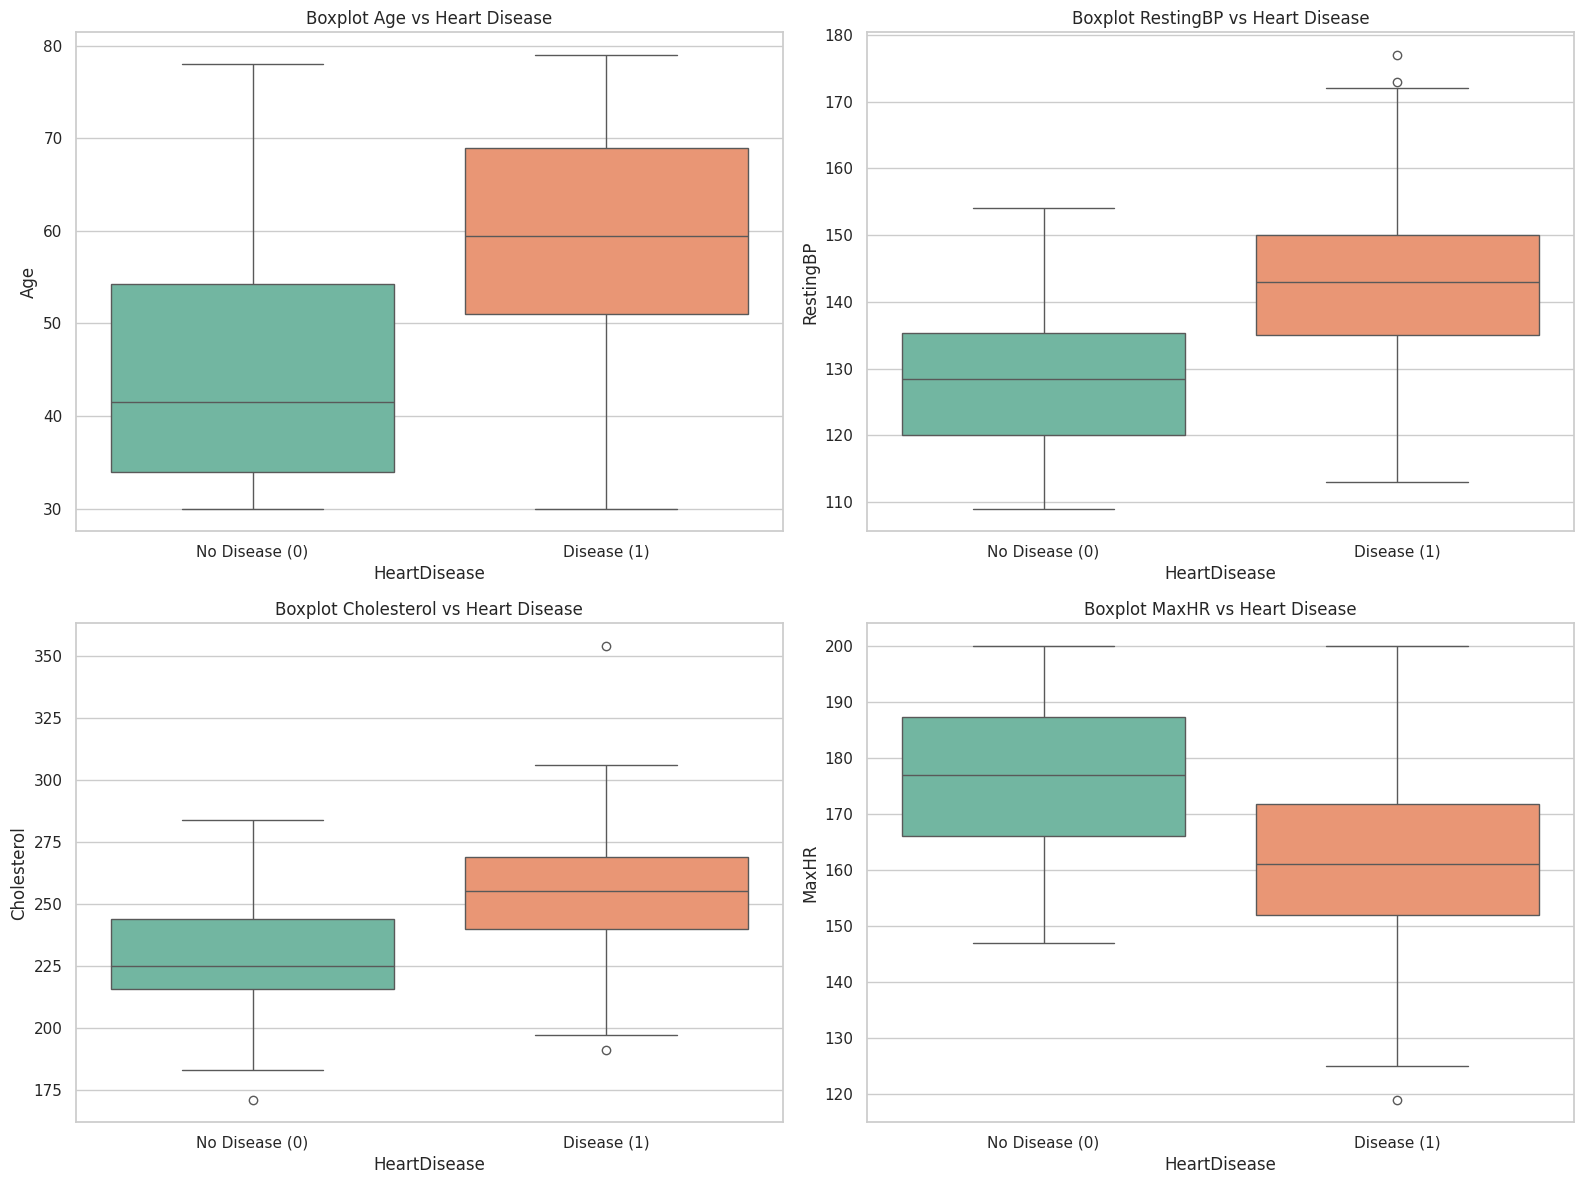

Insight Boxplot:
- Age & RestingBP: Pasien positif cenderung memiliki rentang usia dan tekanan darah yang lebih tinggi.
- Cholesterol: Terdapat beberapa outlier (titik di luar whiskers) yang menunjukkan nilai kolesterol ekstrem pada kedua kelompok.
- MaxHR: Biasanya menunjukkan median yang berbeda secara signifikan antara kelompok sehat dan sakit.


In [115]:
# 2.3 Boxplot Analysis for Outlier & Range Detection
if not df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    box_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR']

    for i, col in enumerate(box_features):
        r, c = i // 2, i % 2
        sns.boxplot(data=df, x='HeartDisease', y=col, ax=axes[r, c], palette='Set2')
        axes[r, c].set_title(f'Boxplot {col} vs Heart Disease')
        axes[r, c].set_xticklabels(['No Disease (0)', 'Disease (1)'])

    plt.tight_layout()
    plt.show()

    print("Insight Boxplot:")
    print("- Age & RestingBP: Pasien positif cenderung memiliki rentang usia dan tekanan darah yang lebih tinggi.")
    print("- Cholesterol: Terdapat beberapa outlier (titik di luar whiskers) yang menunjukkan nilai kolesterol ekstrem pada kedua kelompok.")
    print("- MaxHR: Biasanya menunjukkan median yang berbeda secara signifikan antara kelompok sehat dan sakit.")

## 3. Data Preparation (Preprocessing)
Handle Data kategorikal dan scaling fitur numerik.

In [116]:
if not df.empty:
    # Drop Patient_ID as it has no predictive power
    if 'Patient_ID' in df.columns:
        df = df.drop('Patient_ID', axis=1)

    target = 'HeartDisease'
    X = df.drop(target, axis=1)
    y = df[target]

    # Identify numeric and categorical columns
    num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

    # Separate binary and multi-category columns
    binary_cols = [col for col in cat_cols if X[col].nunique() == 2]
    multi_cols = [col for col in cat_cols if X[col].nunique() > 2]

    print("Numerical Columns:", num_cols)
    print("Binary Categorical:", binary_cols)
    print("Multi Categorical:", multi_cols)

    # 1. Label Encoding for Binary Categories
    label_encoders = {}
    for col in binary_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        label_encoders[col] = le

    # 2. One-Hot Encoding for Multi-Category
    X = pd.get_dummies(X, columns=multi_cols, drop_first=True)

    # Save Expected Feature Names after encoding
    expected_features = X.columns.tolist()

    # Train-Test Split (80% Train, 20% Test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # 3. Feature Scaling
    scaler = StandardScaler()
    X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test[num_cols] = scaler.transform(X_test[num_cols])

    # Save artifacts for deployment
    joblib.dump(label_encoders, 'models/label_encoders.pkl')
    joblib.dump(scaler, 'models/scaler.pkl')
    joblib.dump(expected_features, 'models/expected_features.pkl')
    joblib.dump(num_cols, 'models/num_cols.pkl')

    print("\nPreprocessing Complete. Artifacts saved.")
    print("Training Set Shape:", X_train.shape)
    print("Testing Set Shape:", X_test.shape)

Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'BMI', 'StressLevel']
Binary Categorical: ['Gender', 'ExerciseAngina', 'Smoking', 'FamilyHistory']
Multi Categorical: ['ChestPain', 'PhysicalActivity']

Preprocessing Complete. Artifacts saved.
Training Set Shape: (200, 16)
Testing Set Shape: (50, 16)


## 4. Model Building & Hyperparameter Tuning

In [117]:
# Model 1: Logistic Regression with GridSearchCV
if not df.empty:
    print("Tuning Logistic Regression...")
    lr_params = {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'lbfgs']
    }

    lr_grid = GridSearchCV(
        LogisticRegression(max_iter=1000, random_state=42),
        param_grid=lr_params,
        cv=10,
        scoring='accuracy',
        n_jobs=-1
    )
    lr_grid.fit(X_train, y_train)
    best_lr = lr_grid.best_estimator_
    print(f"Best LR Params: {lr_grid.best_params_}")

Tuning Logistic Regression...
Best LR Params: {'C': 0.1, 'solver': 'liblinear'}


In [118]:
# Model 2: Random Forest Classifier with RandomizedSearchCV
if not df.empty:
    print("Tuning Random Forest...")
    rf_params = {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }

    rf_random = RandomizedSearchCV(
        RandomForestClassifier(random_state=42),
        param_distributions=rf_params,
        n_iter=10,
        cv=10,
        scoring='accuracy',
        random_state=42,
        n_jobs=-1
    )
    rf_random.fit(X_train, y_train)
    best_rf = rf_random.best_estimator_
    print(f"Best RF Params: {rf_random.best_params_}")

Tuning Random Forest...
Best RF Params: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}


## 5. Model Evaluation

--- Logistic Regression Evaluation ---
Accuracy : 0.8200
Precision: 0.8571
Recall   : 0.8824
F1-score : 0.8696
ROC-AUC  : 0.8713



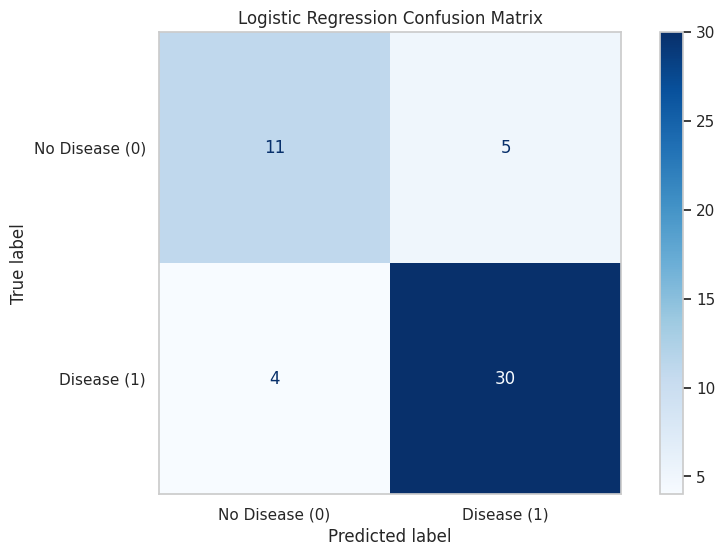

--- Random Forest Evaluation ---
Accuracy : 0.8000
Precision: 0.8529
Recall   : 0.8529
F1-score : 0.8529
ROC-AUC  : 0.8511



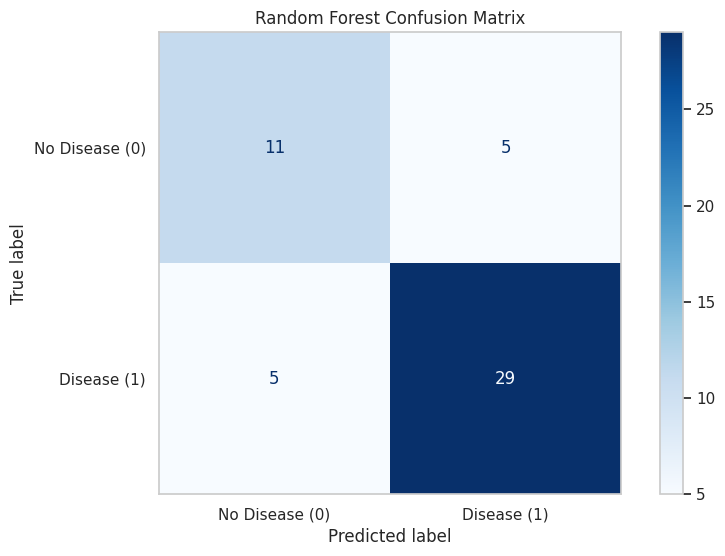

In [119]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred

    print(f"--- {model_name} Evaluation ---")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
    print(f"F1-score : {f1_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}\n")

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease (0)', 'Disease (1)'])
    disp.plot(cmap='Blues')
    plt.title(f'{model_name} Confusion Matrix')
    plt.grid(False) # Turn off grid for confusion matrix
    plt.show()

if not df.empty:
    evaluate_model(best_lr, X_test, y_test, "Logistic Regression")
    evaluate_model(best_rf, X_test, y_test, "Random Forest")

## 6. Model Interpretation

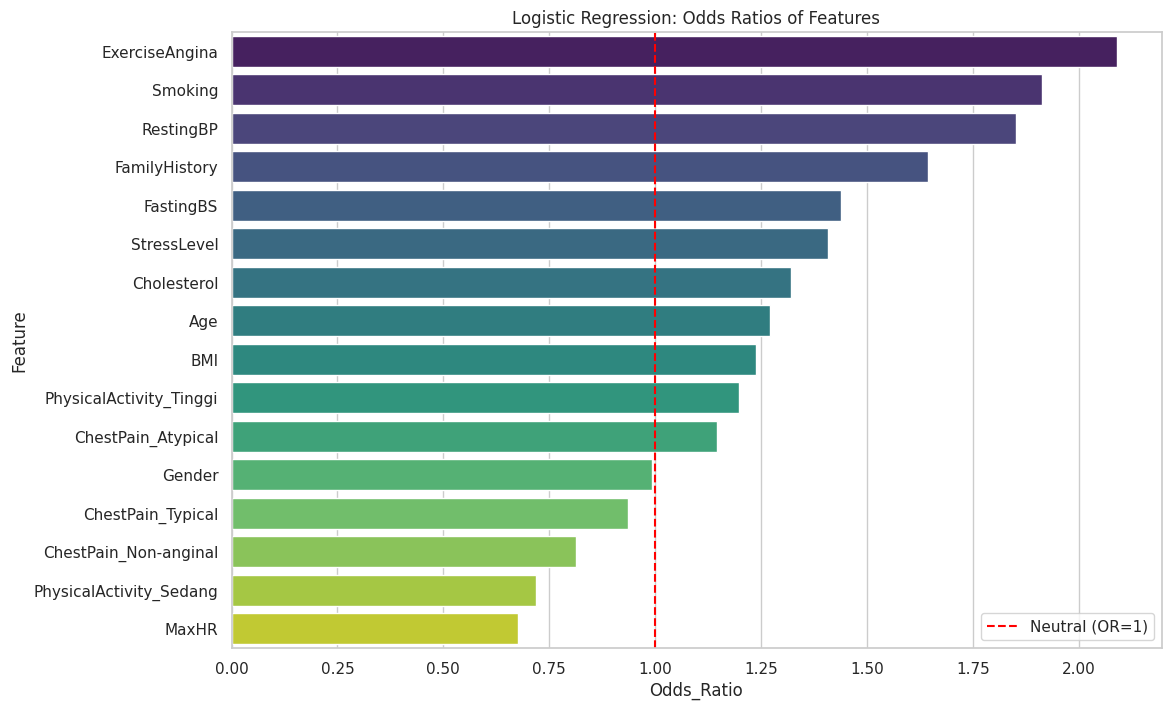

In [120]:
if not df.empty:
    # Logistic Regression Odds Ratios
    odds_ratios = pd.DataFrame({
        'Feature': X.columns,
        'Odds_Ratio': np.exp(best_lr.coef_[0])
    }).sort_values(by='Odds_Ratio', ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(x='Odds_Ratio', y='Feature', data=odds_ratios, palette='viridis')
    plt.axvline(1, color='red', linestyle='--', label='Neutral (OR=1)')
    plt.title('Logistic Regression: Odds Ratios of Features')
    plt.legend()
    plt.show()

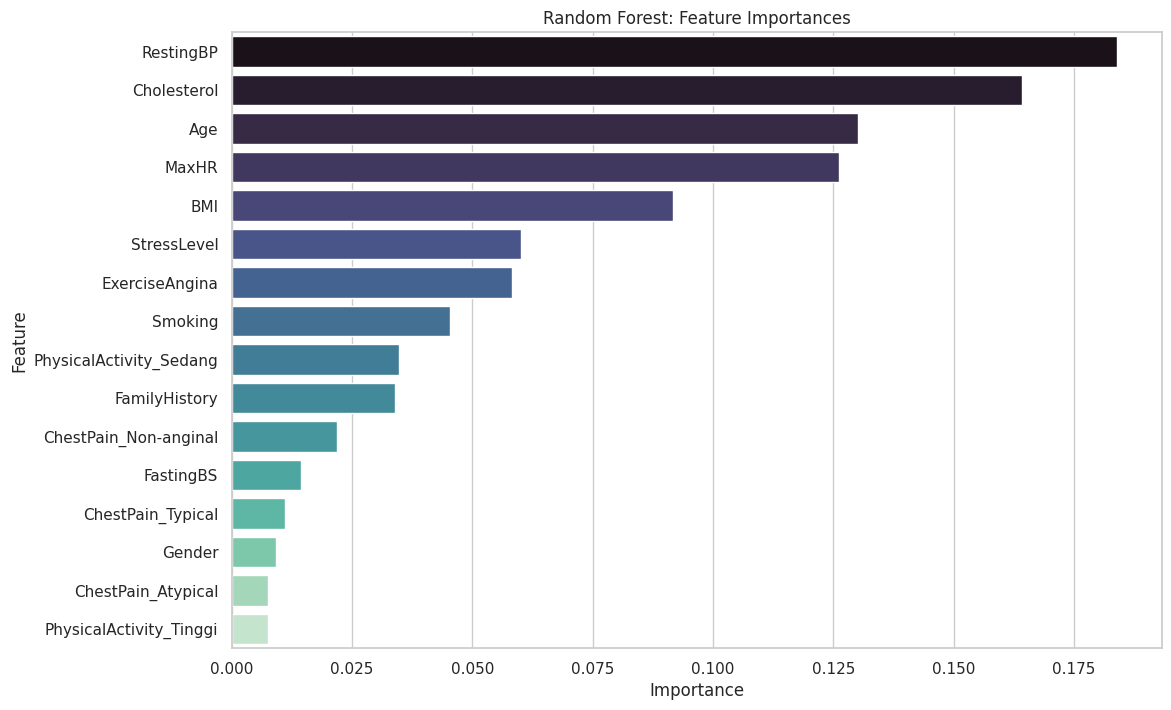

In [121]:
if not df.empty:
    # Random Forest Feature Importance
    importances = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_rf.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=importances, palette='mako')
    plt.title('Random Forest: Feature Importances')
    plt.show()

## 7. Export & Deployment
Saving the best model to the local `models/` directory for deployment.

In [122]:
if not df.empty:
    # Save Models
    joblib.dump(best_rf, 'models/best_rf_model.pkl')
    joblib.dump(best_lr, 'models/best_lr_model.pkl')
    print("Saved models and preprocessing artifacts to 'models/' folder.")
    print("Artifacts ready for download from Colab.")

Saved models and preprocessing artifacts to 'models/' folder.
Artifacts ready for download from Colab.
